<a href="https://colab.research.google.com/github/241541601038-glitch/JALIZ/blob/main/EX06CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving download.jpg to download.jpg


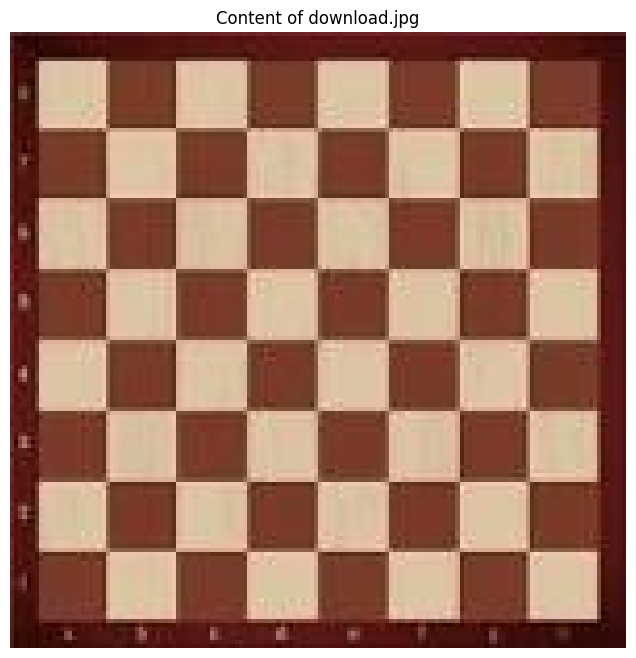

Intrinsic matrix:
 [[966.44480495   0.          61.67267663]
 [  0.         975.82024859 167.79569235]
 [  0.           0.           1.        ]]
Extrinsic parameters:
 [(array([[0.08936393],
       [0.30615428],
       [1.57086444]]), array([[ 3.77071642],
       [-8.45502218],
       [54.25860418]]))]


In [ ]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
objp = np.zeros((6*7, 3), np.float32)
objp[:, :2] = np.mgrid[0:7, 0:6].T.reshape(-1, 2)

objpoints = []
imgpoints = []
img_display = cv2.imread('/content/download.jpg')

if img_display is not None:

    img_display_rgb = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_display_rgb)
    plt.title('Content of download.jpg')
    plt.axis('off')
    plt.show()
else:
    print("Error: Could not load the image for display. Please ensure 'download.png' exists and is not corrupted.")

images = glob.glob('/content/download.jpg')

if not images:
    print("No image file 'download.png' found in /content/. Please upload the image or change the path to proceed with calibration.")
else:
    for img_path in images:
        img = cv2.imread(img_path)
        if img is None:
            print(f"Could not load image from {img_path}. Skipping.")
            continue

        gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
        ret, corners = cv2.findChessboardCorners(gray, (7, 6), None)

        if ret:
            objpoints.append(objp)
            imgpoints.append(corners)
            ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
            print("Intrinsic matrix:\n", mtx)
            print("Extrinsic parameters:\n", list(zip(rvecs, tvecs)))
        else:
            print(f"No chessboard corners found in {img_path}. Skipping calibration for this image.")